In [1]:
import pandas as pd
orders = pd.read_csv("olist_orders_dataset.csv")
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [2]:
orders.shape

(99441, 8)

In [3]:
orders.columns

Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date'],
      dtype='str')

In [4]:
orders["order_status"].value_counts()

order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

In [5]:
orders.isna().sum()

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

In [6]:
#two culprits
orders[(orders["order_status"] == "delivered") & (orders["order_delivered_customer_date"].isna())]

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
3002,2d1e2d5bf4dc7227b3bfebb81328c15f,ec05a6d8558c6455f0cbbd8a420ad34f,delivered,2017-11-28 17:44:07,2017-11-28 17:56:40,2017-11-30 18:12:23,NaN,2017-12-18 00:00:00
20618,f5dd62b788049ad9fc0526e3ad11a097,5e89028e024b381dc84a13a3570decb4,delivered,2018-06-20 06:58:43,2018-06-20 07:19:05,2018-06-25 08:05:00,NaN,2018-07-16 00:00:00
43834,2ebdfc4f15f23b91474edf87475f108e,29f0540231702fda0cfdee0a310f11aa,delivered,2018-07-01 17:05:11,2018-07-01 17:15:12,2018-07-03 13:57:00,NaN,2018-07-30 00:00:00
79263,e69f75a717d64fc5ecdfae42b2e8e086,cfda40ca8dd0a5d486a9635b611b398a,delivered,2018-07-01 22:05:55,2018-07-01 22:15:14,2018-07-03 13:57:00,NaN,2018-07-30 00:00:00
82868,0d3268bad9b086af767785e3f0fc0133,4f1d63d35fb7c8999853b2699f5c7649,delivered,2018-07-01 21:14:02,2018-07-01 21:29:54,2018-07-03 09:28:00,NaN,2018-07-24 00:00:00
92643,2d858f451373b04fb5c984a1cc2defaf,e08caf668d499a6d643dafd7c5cc498a,delivered,2017-05-25 23:22:43,2017-05-25 23:30:16,NaN,NaN,2017-06-23 00:00:00
97647,ab7c89dc1bf4a1ead9d6ec1ec8968a84,dd1b84a7286eb4524d52af4256c0ba24,delivered,2018-06-08 12:09:39,2018-06-08 12:36:39,2018-06-12 14:10:00,NaN,2018-06-26 00:00:00
98038,20edc82cf5400ce95e1afacc25798b31,28c37425f1127d887d7337f284080a0f,delivered,2018-06-27 16:09:12,2018-06-27 16:29:30,2018-07-03 19:26:00,NaN,2018-07-19 00:00:00


In [7]:
date_cols = ["order_purchase_timestamp", "order_approved_at",
             "order_delivered_carrier_date", "order_delivered_customer_date",
             "order_estimated_delivery_date"]
for col in date_cols:
    orders[col] = pd.to_datetime(orders[col])

In [8]:
delivered = orders[(orders["order_status"] == "delivered") &
                   (orders["order_delivered_customer_date"].notna())].copy()
delivered["is_late"] = delivered["order_delivered_customer_date"] > delivered["order_estimated_delivery_date"]
delivered["is_late"].mean() * 100

np.float64(8.112366538820359)

In [9]:
reviews = pd.read_csv("olist_order_reviews_dataset.csv")
reviews.head()

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53


In [10]:
merged = delivered.merge(reviews, on="order_id", how="inner")
merged.shape

(96353, 15)

In [11]:
merged.groupby("is_late")["review_score"].mean()

is_late
False    4.293718
True     2.566494
Name: review_score, dtype: float64

In [12]:
#Verify
reviews["order_id"].duplicated().sum()

np.int64(551)

In [13]:
#Dedup
reviews["review_creation_date"] = pd.to_datetime(reviews["review_creation_date"])
reviews_dedup = (reviews.sort_values("review_creation_date")
                        .drop_duplicates("order_id", keep="last"))
merged = delivered.merge(reviews_dedup, on="order_id", how="inner")
merged.groupby("is_late")["review_score"].mean()

is_late
False    4.294001
True     2.565331
Name: review_score, dtype: float64

In [14]:
#Distribution
merged.groupby("is_late")["review_score"].value_counts(normalize=True).unstack().round(3)

review_score,1,2,3,4,5
is_late,,,,,
False,0.066,0.026,0.080,0.204,0.624
True,0.462,0.078,0.114,0.123,0.222


On-time 1-star rate: 6.6%
Late 1-star rate:    46.2%


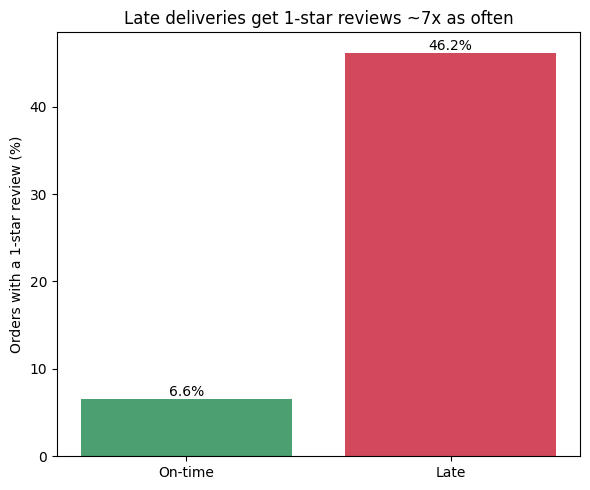

In [15]:
import pandas as pd
import matplotlib.pyplot as plt   # matplotlib = Python's basic charting library

# 1. Load the two tables we need
orders  = pd.read_csv("olist_orders_dataset.csv")
reviews = pd.read_csv("olist_order_reviews_dataset.csv")

# 2. Keep only delivered orders that actually have a delivery date
orders = orders[orders["order_status"] == "delivered"].copy()
orders = orders.dropna(subset=["order_delivered_customer_date"])

# 3. Turn the two date columns into real dates so we can compare them
for col in ["order_delivered_customer_date", "order_estimated_delivery_date"]:
    orders[col] = pd.to_datetime(orders[col])

# 4. Flag late orders (delivered AFTER the estimated date)
orders["is_late"] = orders["order_delivered_customer_date"] > orders["order_estimated_delivery_date"]

# 5. Attach each order's review score (inner join on order_id)
df = orders.merge(reviews[["order_id", "review_score"]], on="order_id", how="inner")

# 6. One review per order (your dedup finding)
df = df.drop_duplicates(subset="order_id")

# 7. For on-time vs late, what % of orders got exactly 1 star?
rate = df.groupby("is_late")["review_score"].apply(lambda s: (s == 1).mean() * 100)
on_time_rate = rate[False]
late_rate    = rate[True]
print(f"On-time 1-star rate: {on_time_rate:.1f}%")
print(f"Late 1-star rate:    {late_rate:.1f}%")

# 8. Draw the bar chart
fig, ax = plt.subplots(figsize=(6, 5))          # fig = the picture, ax = the plot inside it
bars = ax.bar(["On-time", "Late"], [on_time_rate, late_rate],
              color=["#4c9f70", "#d1495b"])
ax.set_ylabel("Orders with a 1-star review (%)")
ax.set_title("Late deliveries get 1-star reviews ~7x as often")
ax.bar_label(bars, fmt="%.1f%%")                # writes the number on top of each bar
plt.tight_layout()

# 9. Save it as an image file for the README, then show it
plt.savefig("one_star_rate.png", dpi=150)
plt.show()

In [16]:
import pandas as pd

orders   = pd.read_csv("olist_orders_dataset.csv")
items    = pd.read_csv("olist_order_items_dataset.csv")
products = pd.read_csv("olist_products_dataset.csv")
trans    = pd.read_csv("product_category_name_translation.csv")

# Same late flag as before
orders = orders[orders["order_status"] == "delivered"].dropna(subset=["order_delivered_customer_date"]).copy()
for c in ["order_delivered_customer_date", "order_estimated_delivery_date"]:
    orders[c] = pd.to_datetime(orders[c])
orders["is_late"] = orders["order_delivered_customer_date"] > orders["order_estimated_delivery_date"]

# Walk order -> items -> product -> english category name
oi = (orders[["order_id", "is_late"]]
      .merge(items[["order_id", "product_id"]], on="order_id", how="inner")
      .merge(products[["product_id", "product_category_name"]], on="product_id", how="left")
      .merge(trans, on="product_category_name", how="left"))

# Late rate and volume per category
g = oi.groupby("product_category_name_english").agg(
        items=("is_late", "size"),
        late_rate=("is_late", "mean"))
g["late_rate"] = (g["late_rate"] * 100).round(1)

# Only categories with real volume, worst first
top = g[g["items"] >= 500].sort_values("late_rate", ascending=False)
print(f"Overall late rate: {oi['is_late'].mean()*100:.1f}%\n")
print("Highest late-rate categories (>=500 items):")
print(top.head(10))

Overall late rate: 7.9%

Highest late-rate categories (>=500 items):
                               items  late_rate
product_category_name_english                  
electronics                     2729        9.7
health_beauty                   9465        9.1
office_furniture                1668        8.9
baby                            2982        8.8
musical_instruments              651        8.6
furniture_decor                 8160        8.4
bed_bath_table                 10953        8.4
auto                            4139        8.3
telephony                       4430        8.3
watches_gifts                   5857        8.3


In [17]:
import pandas as pd

orders = pd.read_csv("olist_orders_dataset.csv")
cust   = pd.read_csv("olist_customers_dataset.csv")

orders = orders[orders["order_status"] == "delivered"].dropna(subset=["order_delivered_customer_date"]).copy()
for c in ["order_delivered_customer_date", "order_estimated_delivery_date"]:
    orders[c] = pd.to_datetime(orders[c])
orders["is_late"] = orders["order_delivered_customer_date"] > orders["order_estimated_delivery_date"]

# Bring in each order's destination state
df = orders.merge(cust[["customer_id", "customer_state"]], on="customer_id", how="left")

g = df.groupby("customer_state").agg(orders=("is_late", "size"),
                                     late_rate=("is_late", "mean"))
g["late_rate"] = (g["late_rate"] * 100).round(1)
g = g[g["orders"] >= 200].sort_values("late_rate", ascending=False)

print(f"Overall late rate: {df['is_late'].mean()*100:.1f}%\n")
print("Worst states:\n", g.head(8).to_string())
print("\nBest states:\n", g.tail(5).to_string())

Overall late rate: 8.1%

Worst states:
                 orders  late_rate
customer_state                   
AL                 397       23.9
MA                 717       19.7
PI                 476       16.0
CE                1279       15.3
SE                 335       15.2
BA                3256       14.0
RJ               12350       13.5
TO                 274       12.8

Best states:
                 orders  late_rate
customer_state                   
MT                 886        6.8
SP               40494        5.9
MG               11354        5.6
PR                4923        5.0
RO                 243        2.9


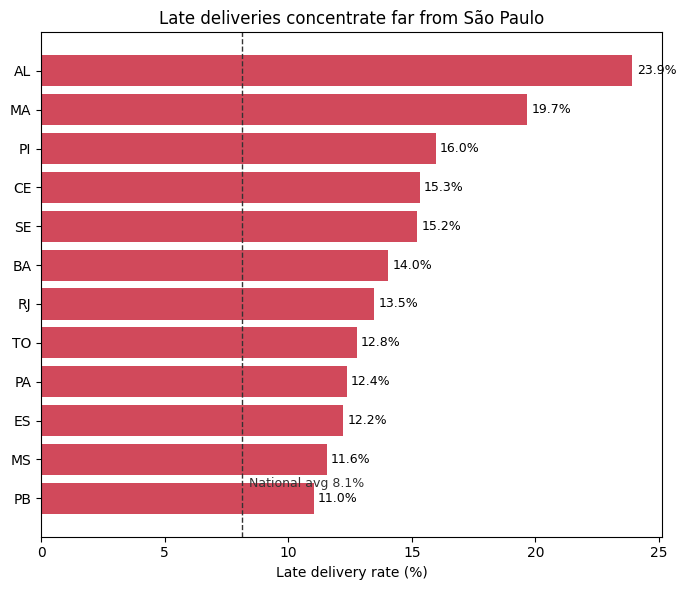

In [18]:
import pandas as pd
import matplotlib.pyplot as plt

orders = pd.read_csv("olist_orders_dataset.csv")
cust   = pd.read_csv("olist_customers_dataset.csv")

orders = orders[orders["order_status"] == "delivered"].dropna(subset=["order_delivered_customer_date"]).copy()
for c in ["order_delivered_customer_date", "order_estimated_delivery_date"]:
    orders[c] = pd.to_datetime(orders[c])
orders["is_late"] = orders["order_delivered_customer_date"] > orders["order_estimated_delivery_date"]
df = orders.merge(cust[["customer_id", "customer_state"]], on="customer_id", how="left")

g = df.groupby("customer_state").agg(orders=("is_late", "size"), late_rate=("is_late", "mean"))
g["late_rate"] = g["late_rate"] * 100
g = g[g["orders"] >= 200].sort_values("late_rate")
overall = df["is_late"].mean() * 100
worst = g.tail(12)          # the 12 worst states

fig, ax = plt.subplots(figsize=(7, 6))
colors = ["#d1495b" if v > overall else "#4c9f70" for v in worst["late_rate"]]
bars = ax.barh(worst.index, worst["late_rate"], color=colors)
ax.axvline(overall, color="#333", linestyle="--", linewidth=1)
ax.text(overall + 0.3, 0.3, f"National avg {overall:.1f}%", color="#333", fontsize=9)
ax.set_xlabel("Late delivery rate (%)")
ax.set_title("Late deliveries concentrate far from São Paulo")
ax.bar_label(bars, fmt="%.1f%%", padding=3, fontsize=9)
plt.tight_layout()
plt.savefig("state_late_rate.png", dpi=150)
plt.show()

In [19]:
import pandas as pd

orders  = pd.read_csv("olist_orders_dataset.csv")
cust    = pd.read_csv("olist_customers_dataset.csv")
reviews = pd.read_csv("olist_order_reviews_dataset.csv")

orders = orders[orders["order_status"] == "delivered"].dropna(subset=["order_delivered_customer_date"]).copy()
for c in ["order_delivered_customer_date", "order_estimated_delivery_date"]:
    orders[c] = pd.to_datetime(orders[c])
orders["is_late"] = orders["order_delivered_customer_date"] > orders["order_estimated_delivery_date"]

df = orders.merge(cust[["customer_id", "customer_state"]], on="customer_id", how="left")
reviews = reviews.sort_values("review_creation_date").drop_duplicates("order_id", keep="last")
df = df.merge(reviews[["order_id", "review_score"]], on="order_id", how="inner")
df["is_1star"] = df["review_score"] == 1

national_late = df["is_late"].mean()
sp_late = df[df["customer_state"] == "SP"]["is_late"].mean()
p1_late   = df[df["is_late"]]["is_1star"].mean()
p1_ontime = df[~df["is_late"]]["is_1star"].mean()

rj = df[df["customer_state"] == "RJ"]
rj_orders, rj_late = len(rj), rj["is_late"].sum()
print(f"RJ today: {rj_orders:,} orders, {rj_late:,} late ({rj['is_late'].mean()*100:.1f}%)")
print(f"1-star rate: late {p1_late*100:.1f}% vs on-time {p1_ontime*100:.1f}%\n")

for label, target in [("national avg", national_late), ("São Paulo level", sp_late)]:
    fixed = rj_late - target * rj_orders          # late orders eliminated
    recovered = fixed * (p1_late - p1_ontime)     # fewer 1-star reviews
    print(f"RJ -> {label} ({target*100:.1f}%): ~{fixed:,.0f} fewer late orders, ~{recovered:,.0f} fewer 1-star reviews")

RJ today: 12,211 orders, 1,623 late (13.3%)
1-star rate: late 46.2% vs on-time 6.6%

RJ -> national avg (8.0%): ~647 fewer late orders, ~256 fewer 1-star reviews
RJ -> São Paulo level (5.8%): ~911 fewer late orders, ~361 fewer 1-star reviews
